In [1]:
# Instalamos funcionalidades 
%pip install folium mapclassify
%pip install scikit-learn geopandas pandas numpy pyogrio
%pip install seaborn matplotlib statsmodels
%pip install libpysal spreg

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Lectura de Librerías 
import geopandas as gpd
import pandas as pd
import numpy as np
from sklearn.cluster import AgglomerativeClustering, KMeans
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# Carga de Datos (Boston)

url = "https://github.com/Nowosad/spData/raw/master/inst/shapes/boston_tracts.gpkg"
gdf = gpd.read_file(url)

print(gdf.head())
print(gdf.columns)

  poltract                     TOWN  TOWNNO  TRACT      LON      LAT  MEDV  \
0     0001  Boston Allston-Brighton    74.0    1.0 -71.0830  42.2172  17.8   
1     0002  Boston Allston-Brighton    74.0    2.0 -71.0950  42.2120  21.7   
2     0003  Boston Allston-Brighton    74.0    3.0 -71.1007  42.2100  22.7   
3     0004  Boston Allston-Brighton    74.0    4.0 -71.0930  42.2070  22.6   
4     0005  Boston Allston-Brighton    74.0    5.0 -71.0905  42.2033  25.0   

   CMEDV     CRIM   ZN  ...  C20_25 C25_35  C35_50  co50k   median   BB  \
0   17.8  8.98296  0.0  ...      29     16       1      1  17800.0  0.8   
1   21.7  3.84970  0.0  ...     139     93       9      5  21700.0  1.4   
2   22.7  5.20177  0.0  ...     127    102      24      0  22700.0  0.3   
3   22.6  4.26131  0.0  ...      67     63      12      3  22600.0  0.8   
4   25.0  4.54192  0.0  ...       9     12       9      1  25000.0  1.8   

   censored  NOX_ID   POP                                           geometry  
0

In [5]:
# Creación variable objetivo y explicativas

gdf["price"] = pd.to_numeric(gdf["CMEDV"], errors="coerce")
gdf["log_price"] = np.log(gdf["price"])

gdf["CRIM"] = pd.to_numeric(gdf["CRIM"], errors="coerce")
gdf["DIS"] = pd.to_numeric(gdf["DIS"], errors="coerce")

gdf["log_crime"] = np.log1p(gdf["CRIM"])
gdf["log_dis"] = np.log1p(gdf["DIS"])

covariables_list = [
    "log_crime",
    "RM",
    "LSTAT",
    "NOX",
    "log_dis",
    "PTRATIO",
    "TAX",
    "CHAS"
]

target_col = "log_price"

# Asegurar que todas las variables sean numéricas
for col in covariables_list + [target_col]:
    gdf[col] = pd.to_numeric(gdf[col], errors="coerce")

# Eliminar valores no válidos
gdf = gdf.replace([np.inf, -np.inf], np.nan)
gdf = gdf.dropna(subset=covariables_list + [target_col])

gdf = gdf.reset_index(drop=True)

print(gdf[covariables_list + [target_col]].dtypes)
print(gdf.shape)

log_crime    float64
RM           float64
LSTAT        float64
NOX          float64
log_dis      float64
PTRATIO      float64
TAX          float64
CHAS           int64
log_price    float64
dtype: object
(506, 41)


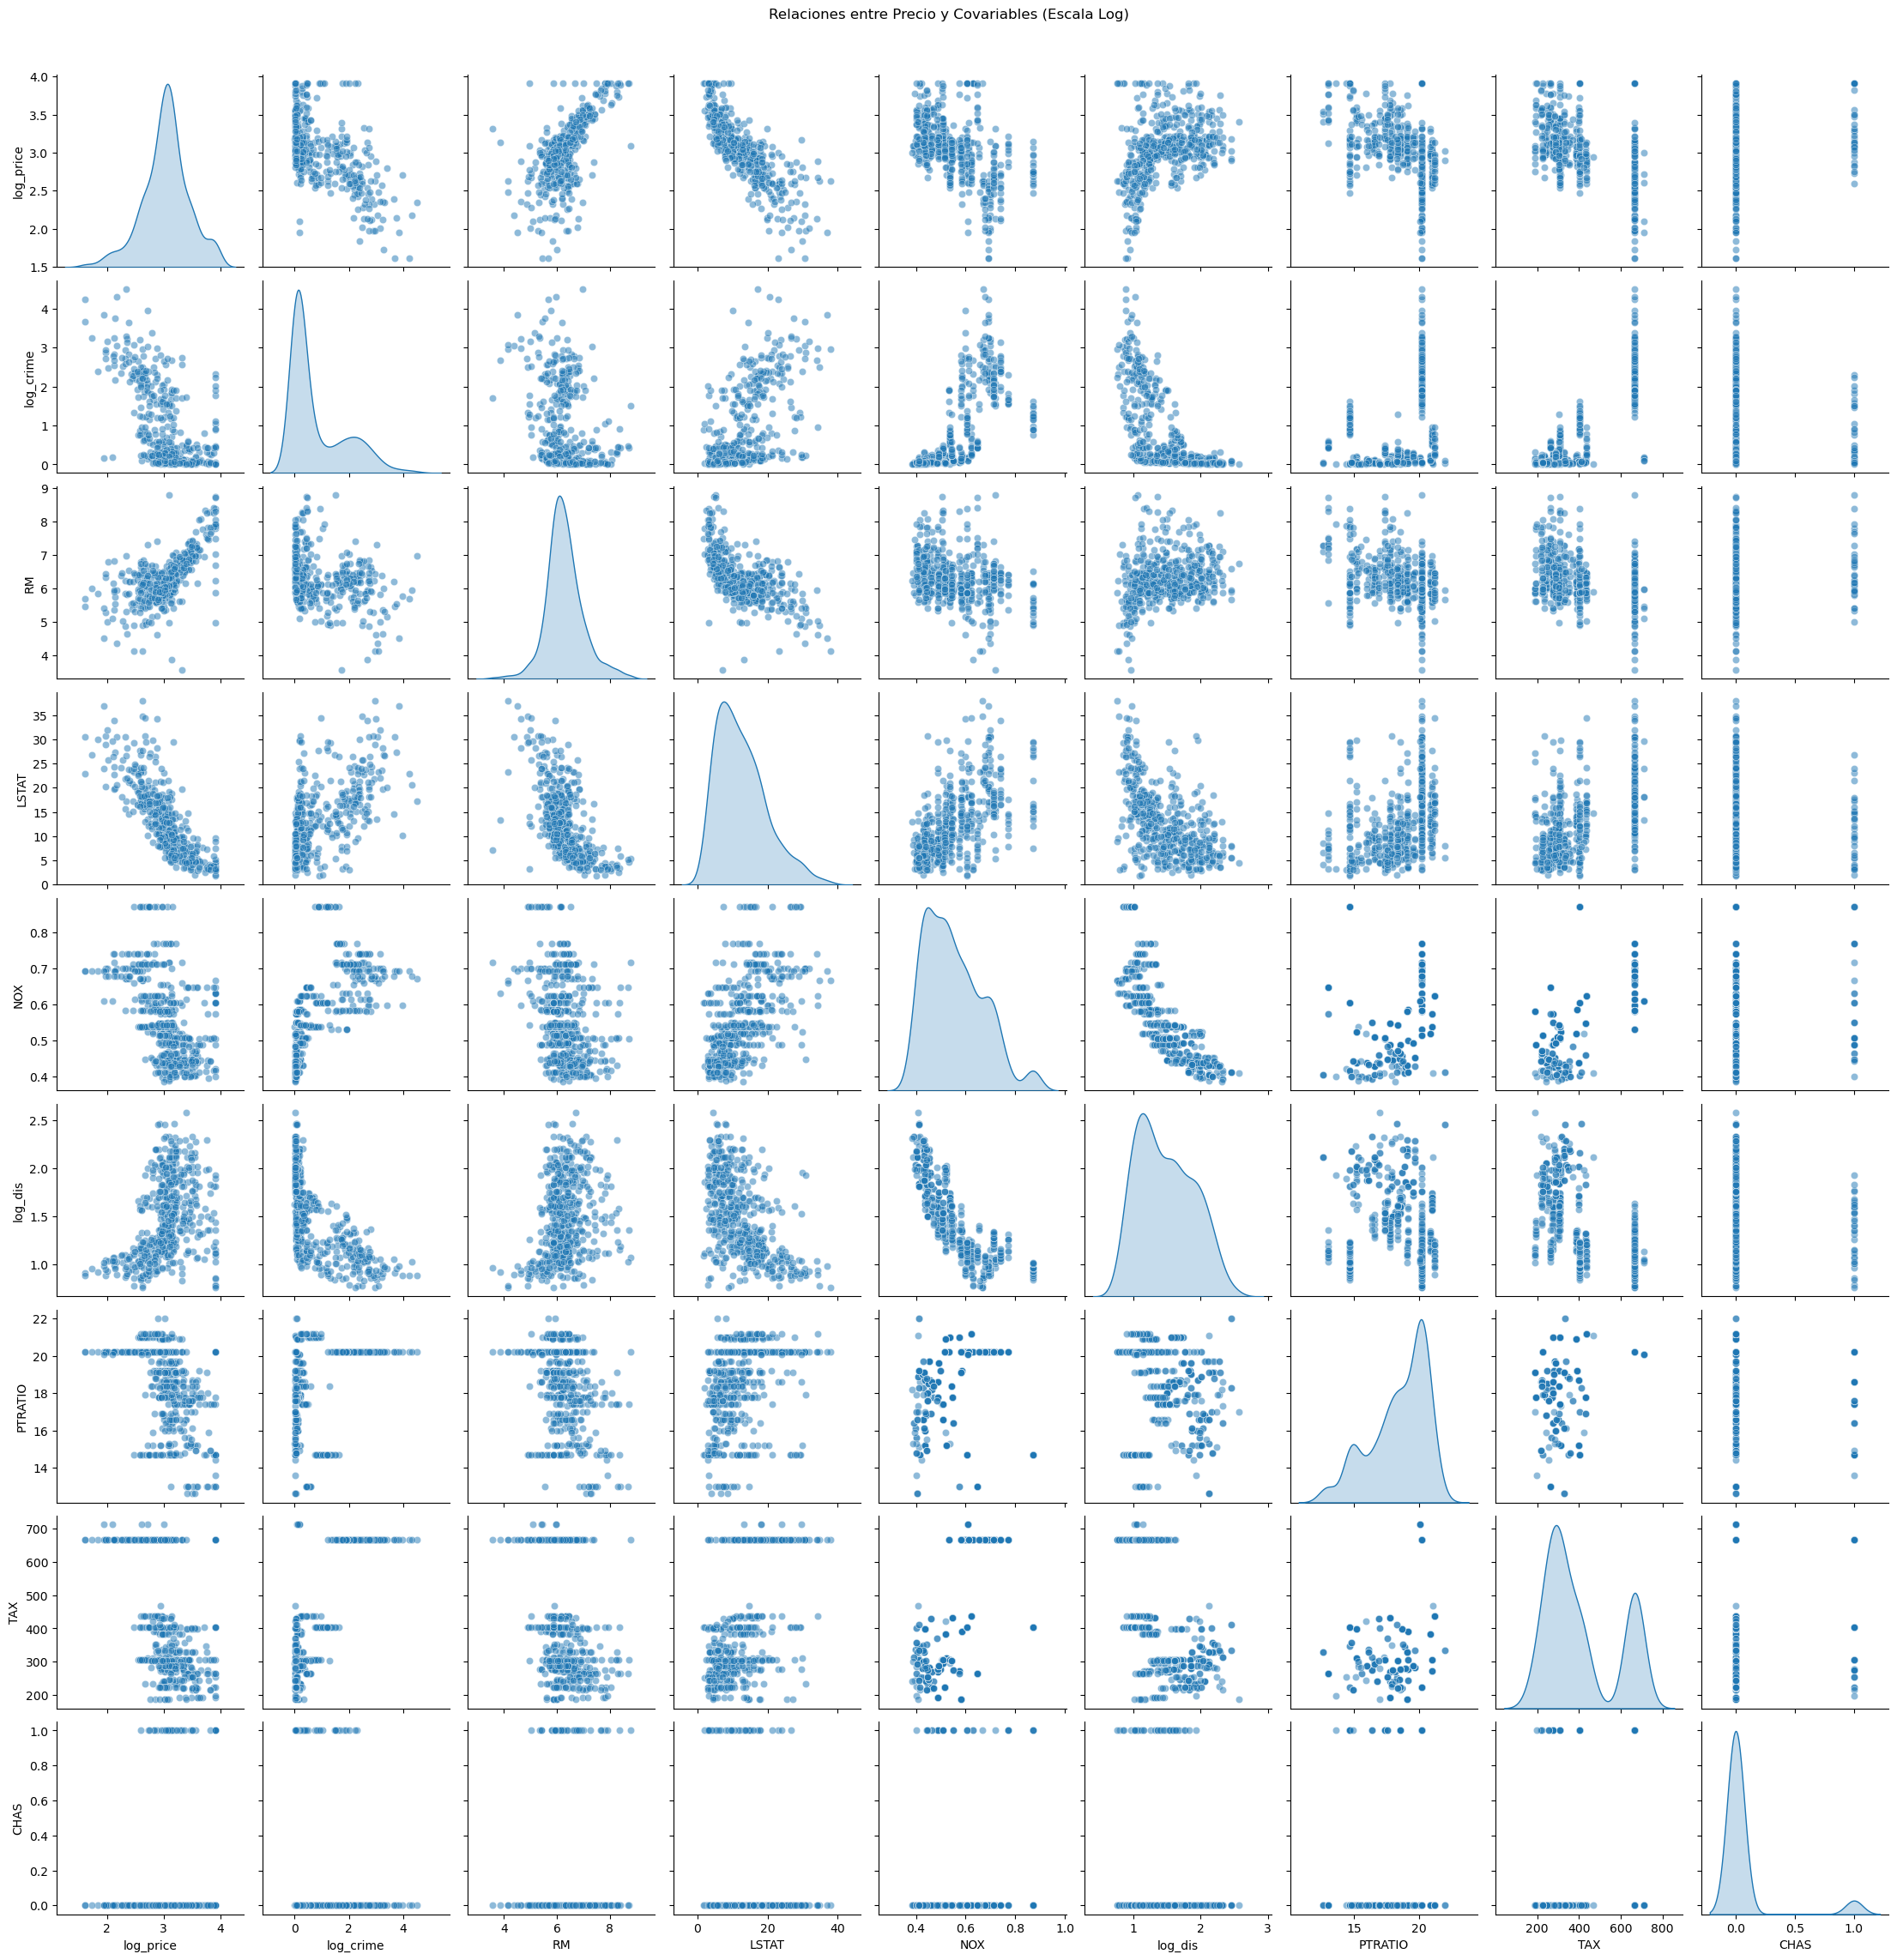

In [6]:
#Visualización en un mapa
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionamos las columnas para el gráfico
cols_to_plot = [target_col] + covariables_list

# Generamos la matriz de dispersión
sns.pairplot(gdf[cols_to_plot], diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle("Relaciones entre Precio y Covariables (Escala Log)", y=1.02)
plt.show()

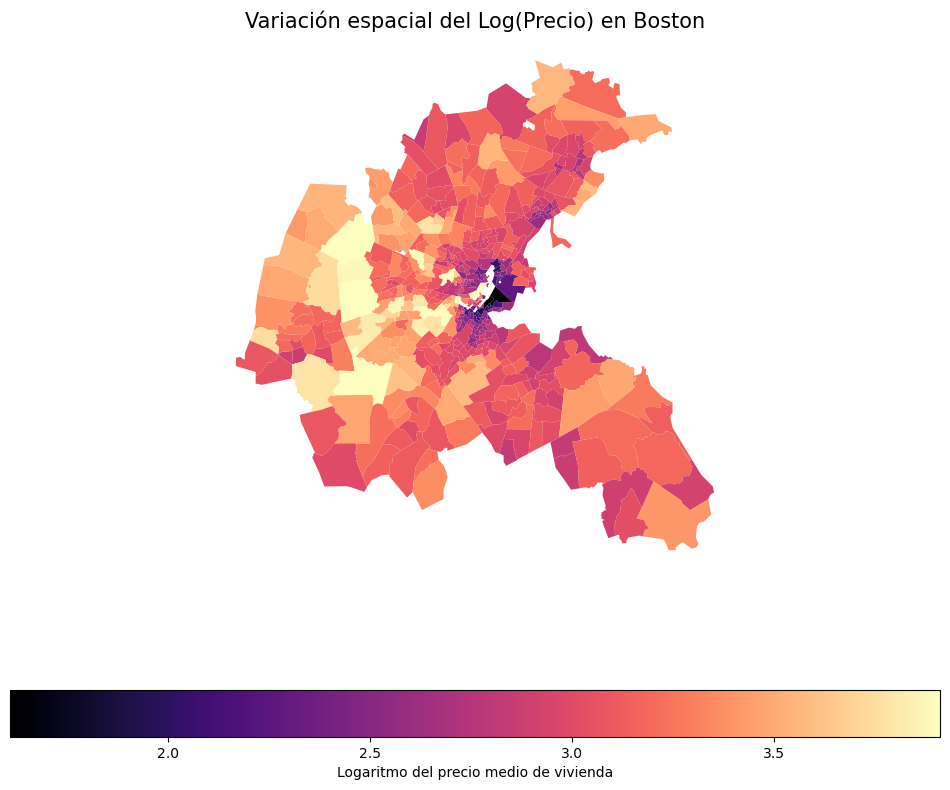

In [7]:
# ------------------------------------------------------------
# 4. MAPA DEL LOG-PRECIO
# ------------------------------------------------------------

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

gdf.plot(
    column="log_price",
    cmap="magma",
    legend=True,
    legend_kwds={
        "label": "Logaritmo del precio medio de vivienda",
        "orientation": "horizontal"
    },
    ax=ax
)

ax.set_title("Variación espacial del Log(Precio) en Boston", fontsize=15)
ax.set_axis_off()

plt.show()

In [8]:
# Mapa Iteractivo

mapa_boston = gdf.explore(
    column="log_price",
    cmap="magma",
    tooltip=["CMEDV", "log_price"],
    popup=True,
    legend=True,
    tiles="CartoDB positron"
)

mapa_boston

In [10]:
!pip install kmodes

In [12]:
# Spatial Plus-CV de Wang
import time
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering
from kmodes.kprototypes import KPrototypes

class sample_point(object):
    def __init__(self, ID = None, coords = None):
        self.ID = ID
        self.coords = coords

class AHC_cluster(object):
    def __init__(self, points = None, count = None):
        self.points = points
        self.count = count

def env_norm(env_array, cate_num):
    env_num = len(env_array[0,:])
    for env_i in range(env_num - cate_num):
        env_i_max = np.max(env_array[:,env_i])
        env_i_min = np.min(env_array[:,env_i])
        # Evitar división por cero si max == min
        if env_i_max != env_i_min:
            env_array[:,env_i] = (env_array[:,env_i]-env_i_min)/(env_i_max-env_i_min)
        else:
            env_array[:,env_i] = 0
    return env_array

def maxAHClustering(sample_points, autoc_threshold = 1):
    maxAHC_clusters_model = AgglomerativeClustering(distance_threshold = autoc_threshold, n_clusters=None, linkage="complete").fit(sample_points[:,1:])
    maxAHC_counts = maxAHC_clusters_model.n_clusters_
    maxAHC_labels = maxAHC_clusters_model.labels_
    maxAHC_clusters = []
    for i in range(maxAHC_counts):
        maxAHC_i_cluster = AHC_cluster(points = [], count = 0)
        for j in range(len(sample_points)):
            if int(maxAHC_labels[j]) == i:
                point = sample_point(ID = j, coords = [sample_points[j,1], sample_points[j,2]])
                maxAHC_i_cluster.points.append(point)
                maxAHC_i_cluster.count += 1
        maxAHC_clusters.append(maxAHC_i_cluster)
    return maxAHC_clusters

def clusters_var(points, env, tar, cate_num, clusters):
    pure_env = env[:,1:]
    pure_normenv = env_norm(pure_env, cate_num)
    clusters_coords, clusters_normenv, clusters_tar = [], [], []
    
    for cluster in clusters:
        coord_sum = [0,0]
        for point in cluster.points:
            sample_point_ID = int(point.ID)
            coord = points[sample_point_ID, 1:]
            coord_sum = [coord_sum[0]+coord[0], coord_sum[1]+coord[1]]
        coord_avg = [coord_sum[0]/float(cluster.count), coord_sum[1]/float(cluster.count)]
        clusters_coords.append(coord_avg)
        
        cluster_env = []
        for i_env in range(len(pure_normenv[0,:])-cate_num):
            i_env_sum = 0
            for point in cluster.points:
                sample_point_ID = int(point.ID)
                i_env_value = pure_normenv[sample_point_ID, i_env]
                i_env_sum += float(i_env_value)
            cluster_env.append(i_env_sum/float(cluster.count))
            
        for i_env in range(cate_num):
            i_env_array = []
            for point in cluster.points:
                sample_point_ID = int(point.ID)
                i_env_value = pure_normenv[sample_point_ID, -(cate_num-i_env)]
                i_env_array.append(i_env_value)
            i_env_array = np.array(i_env_array)
            i_env_valuecounts = np.bincount(i_env_array.astype(int))
            cluster_env.append(np.argmax(i_env_valuecounts))
        clusters_normenv.append(cluster_env)
        
        tar_sum = 0
        for point in cluster.points:
            sample_point_ID = int(point.ID)
            tar_sum += float(tar[sample_point_ID, -1])
        clusters_tar.append([tar_sum/float(cluster.count)])
        
    return np.array(clusters_coords), np.array(clusters_normenv), np.array(clusters_tar)

# ==========================================
# 2. FUNCIÓN DE CONSENSO (SUSTITUYE A CLUSTERENSEMBLES)
# ==========================================
"""
    Combina múltiples soluciones de clustering (runs) en una partición única de consenso.
    Aplica HBGF (Formulación de Grafo Bipartito Mixto) modelando el problema como la partición de un grafo bipartito.
    
    Parámetros:
    -----------
    cluster_runs : np.array de forma (3, n_blocks)
        Contiene las etiquetas de los 3 clusterings previos para cada bloque:
        - cluster_runs[0]: Etiquetas de Ubicación (L)
        - cluster_runs[1]: Etiquetas de Covariables (C)
        - cluster_runs[2]: Etiquetas del Target (T)
    k_folds : int
        Número de folds finales de validación cruzada deseados.
"""
def hbgf_consensus(cluster_runs, k_folds):

    # 1. IDENTIFICACIÓN DE DIMENSIONES
    # n_blocks es la cantidad total de bloques operativos espaciales creados en la Etapa 1.
    n_blocks = cluster_runs.shape[1]
    # 2. CONSTRUCCIÓN DE LA MATRIZ DE PARTICIÓN (H)
    # Crea una matriz binaria donde cada fila es un bloque y cada columna es un clúster específico.
    # Como hay 3 clusterings de tamaño 'k_folds', el total de columnas es 3 * k_folds.
    H = np.zeros((n_blocks, 3 * k_folds))

    for i in range(n_blocks):
        # Si el bloque 'i' pertenece al clúster 'X' geográfico, se marca con 1.
        H[i, cluster_runs[0][i]] = 1
        # Si pertenece al clúster 'Y' de covariables, se marca con 1 (desplazado en el eje de columnas).
        H[i, k_folds + cluster_runs[1][i]] = 1
        # Si pertenece al clúster 'Z' del target, se marca con 1 (desplazado al final de las columnas).
        H[i, 2 * k_folds + cluster_runs[2][i]] = 1

    #3. CONSTRUCCIÓN DEL GRAFO BIPARTITO MIXTO (Matriz de Adyacencia W)
    # El grafo contiene tanto los bloques individuales como los clústeres abstractos como "nodos".
    # El número total de nodos en el grafo es la suma de bloques + columnas de clústeres.
    total_nodes = n_blocks + (3 * k_folds)
    W = np.zeros((total_nodes, total_nodes))
   # Rellenar la matriz de adyacencia del grafo:
    # Bloques se conectan con Clústeres (esquina superior derecha de la matriz)
    W[:n_blocks, n_blocks:] = H
    # Clústeres se conectan de vuelta con los Bloques (esquina inferior izquierda, simétrica)
    W[n_blocks:, :n_blocks] = H.T
    
    # 4. ESTABILIZACIÓN ALGEBRAICA (Ajuste de Auto-afinidad)
    # Coloca 1s en la diagonal principal. Esto modela que cada nodo está conectado perfectamente
    # consigo mismo, asegurando estabilidad matemática y evitando errores de división por cero
    # al calcular la matriz Laplaciana normalizada en el Clustering Espectral.    
    np.fill_diagonal(W, 1)

    sc = SpectralClustering(n_clusters=k_folds, affinity='precomputed', assign_labels='kmeans', n_init=10, random_state=42)
    final_labels = sc.fit_predict(W)
    return final_labels[:n_blocks]

# ==========================================
# 3. FUNCIÓN PRINCIPAL ADAPTADA A GEODATAFRAMES
# ==========================================
def SP_CV_from_gdf(gdf, covariables_list, target_col, cate_num=0, autoc_threshold=1500, folds_k=5):
    print("Iniciando Spatial+ Cross-Validation...")
    starttime = time.time()
    
   # =========================================================================
    # BLOQUE 1: EXTRACCIÓN Y PREPARACIÓN DE MATRICES NUMÉRICAS PURAS
    # =========================================================================
    # Se generan identificadores secuenciales únicos (IDs) para cada fila en formato float.
    ids = np.arange(len(gdf)).astype(np.float64)
    
    # Se extraen los componentes espaciales calculando los centroides de cada polígono.
    x = gdf.geometry.centroid.x.values.astype(np.float64)
    y = gdf.geometry.centroid.y.values.astype(np.float64)
    
    # Se extraen las matrices independientes para el entorno (covariables) y el objetivo (target).
    envs = gdf[covariables_list].values.astype(np.float64)
    tar = gdf[target_col].values.astype(np.float64)
    
    # Se consolidan todas las columnas en una única matriz maestra de datos.
    samples_data = np.column_stack((ids, x, y, envs, tar))
    
    # Se segmenta la matriz maestra en sub-arreglos específicos manteniendo el ID en la primera columna:
    samples_points = samples_data[:, :3]                                  # [ID, X, Y] (Geografía)
    samples_envs = np.hstack((samples_data[:,:1], samples_data[:, 3:-1])) # [ID, Covariables] (Entorno)
    samples_tars = np.hstack((samples_data[:,:1], samples_data[:, -1:]))  # [ID, Target] (Objetivo)
    
    # =========================================================================
    # BLOQUE 2: FASE 1 - AGRUPAMIENTO JERÁRQUICO ESPACIAL (Algoritmo 1 del Paper)
    # =========================================================================
    print(" -> Fase 1: Agrupamiento Jerárquico Espacial (AHC)")
    
    # Agrupa las muestras contiguas usando Clustering Jerárquico con enlace máximo.
    # El algoritmo se detiene cuando los bloques alcanzan el radio del umbral de autocorrelación (1500m).
    SP_blocks = maxAHClustering(samples_points, autoc_threshold)
    
    # Toma las muestras de cada bloque espacial y calcula sus valores representativos promedio:
    # Coordenadas promedio, covariables promedio (normalizadas) y el target promedio de cada bloque.
    clusters_coords, clusters_normenv, clusters_tar = clusters_var(
        samples_points, samples_envs, samples_tars, cate_num, SP_blocks
    )
    
    # =========================================================================
    # BLOQUE 3: FASE 2 - CLUSTERINGS INDEPENDIENTES (Inicio del Algoritmo 2)
    # =========================================================================
    print(" -> Fase 2: K-Means sobre espacio, entorno y objetivo")
    
    # • Ejecución 1: Agrupamiento por localización (Espacio Geográfico) [clusters(L)]
    # Clasifica la posición de los bloques en 'folds_k' clústeres espaciales basados en sus centroides.
    clusters_points_kmeans = KMeans(n_clusters=folds_k, n_init=10, random_state=42).fit(clusters_coords)
    clusters_points_klabels = clusters_points_kmeans.labels_
    
    # • Ejecución 2: Agrupamiento por características del entorno (Espacio de Atributos) [clusters(C)]
    # Si hay variables categóricas usa K-Prototypes; si no, aplica un KMeans estándar sobre los predictores.
    if cate_num > 0:
        clusters_normenv_klabels = KPrototypes(n_clusters=folds_k, init='Cao', verbose=0).fit_predict(
            clusters_normenv, categorical=list(range(len(clusters_normenv)-cate_num, len(clusters_normenv)))
        )
    else:
        clusters_normenv_kmeans = KMeans(n_clusters=folds_k, n_init=10, random_state=42).fit(clusters_normenv)
        clusters_normenv_klabels = clusters_normenv_kmeans.labels_
        
    # • Ejecución 3: Agrupamiento por comportamiento del mercado (Espacio del Target) [clusters(T)]
    # Agrupa los bloques en función de la similitud en sus valores de la variable objetivo.
    clusters_target_kmeans = KMeans(n_clusters=folds_k, n_init=10, random_state=42).fit(clusters_tar)
    clusters_target_klabels = clusters_target_kmeans.labels_
    
    # =========================================================================
    # BLOQUE 4: FASE 3 - FUNCIÓN DE CONSENSO MEDIANTE GRAFOS (HBGF)
    # =========================================================================
    print(" -> Fase 3: Consenso de Grafos Bipartitos (HBGF)")
    
    # Se compilan las tres matrices de etiquetas de clústeres independientes en un solo arreglo.
    cluster_runs = np.array([clusters_points_klabels, clusters_normenv_klabels, clusters_target_klabels])
    
    # Se invoca la función de consenso HBGF para fusionar las tres soluciones en una sola partición final equilibrada.
    ensemble_clustering_labels = hbgf_consensus(cluster_runs, folds_k)
    
    # =========================================================================
    # BLOQUE 5: DESEMPAQUETADO Y MAPEADO HACIA LAS UNIDADES ORIGINALES
    # =========================================================================
    produced_folds = []
    
    # El consenso se calculó a nivel de bloques operativos. Este bucle mapea esa solución
    # de regreso hacia cada una de las observaciones o áreas poligonales individuales de origen.
    for i in range(len(SP_blocks)):
        cluster_id = i
        fold_label = ensemble_clustering_labels[cluster_id] # Obtiene el fold asignado a este bloque
        
        # Itera sobre todas las celdas o puntos contenidos dentro del bloque actual
        for j in range(SP_blocks[cluster_id].count):
            point_id = SP_blocks[cluster_id].points[j].ID
            origin_point_id = int(samples_points[point_id, 0]) # Rescata el índice original del gdf
            
            # Almacena el emparejamiento entre el ID de la fila original y su fold definitivo de SP-CV
            produced_folds.append({'temp_id': origin_point_id, 'fold_spatial_plus': fold_label})
            
    # Consolida los resultados estructurándolos en un DataFrame de Pandas listo para fusionar.
    df_results = pd.DataFrame(produced_folds)
    print(f"¡Proceso completado en {int(time.time() - starttime)} segundos!")
    
    return df_results

In [15]:
# ==========================================
# 4. EJECUCIÓN SOBRE LOS DATOS DE BOSTON
# ==========================================

# Asegurarse de que no haya valores nulos que rompan los algoritmos de scikit-learn
gdf_clean = gdf.dropna(subset=['log_crime', "RM", "LSTAT", "NOX", "log_dis", "PTRATIO", "TAX", "CHAS"]).copy()

# Definir variables del modelo
covariables = ['log_crime', "RM", "LSTAT", "NOX", "log_dis", "PTRATIO", "TAX", "CHAS"]
objetivo = 'log_price'

# Crear un ID temporal para el cruce exacto
gdf_clean['temp_id'] = range(len(gdf_clean))

# Ejecutar el algoritmo Spatial+ (usando 1500 metros como umbral base)
resultados = SP_CV_from_gdf(
    gdf=gdf_clean, 
    covariables_list=covariables, 
    target_col=objetivo, 
    cate_num=0, # Asumimos que todas tus covariables definidas arriba son continuas
    autoc_threshold=0.01, 
    folds_k=5
)

# Unir los pliegues resultantes al dataset principal
gdf = gdf.merge(resultados, on='temp_id', how='left') if 'temp_id' in gdf.columns else gdf_clean.merge(resultados, on='temp_id', how='left')

# Limpiar columnas temporales
if 'temp_id' in gdf.columns:
    gdf = gdf.drop(columns=['temp_id'])

# Comprobar la distribución espacial de la muestra
print("\nDistribución de observaciones por pliegue espacial (fold_spatial_plus):")
print(gdf['fold_spatial_plus'].value_counts())

Iniciando Spatial+ Cross-Validation...
 -> Fase 1: Agrupamiento Jerárquico Espacial (AHC)
 -> Fase 2: K-Means sobre espacio, entorno y objetivo


C:\Users\charl\AppData\Local\Temp\ipykernel_31928\1475666251.py:157: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  x = gdf.geometry.centroid.x.values.astype(np.float64)
C:\Users\charl\AppData\Local\Temp\ipykernel_31928\1475666251.py:158: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  y = gdf.geometry.centroid.y.values.astype(np.float64)
C:\Users\charl\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\charl\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMe

 -> Fase 3: Consenso de Grafos Bipartitos (HBGF)
¡Proceso completado en 0 segundos!

Distribución de observaciones por pliegue espacial (fold_spatial_plus):
fold_spatial_plus
3    131
1    128
4    120
2     88
0     39
Name: count, dtype: int64


In [21]:
import numpy as np
import pandas as pd
from libpysal.weights import Queen
from spreg import ML_Error

# 1. Variables a utilizar
target_col = 'log_price'
covariables_list = ['log_crime', 'rooms', 'sales', 'log_driveshop']
todas_las_columnas = [target_col] + covariables_list + ['fold_spatial_plus', 'geometry']

# 2. Limpieza de NaN e infinitos
gdf_limpio = gdf[todas_las_columnas].replace([np.inf, -np.inf], np.nan)

filas_antes = len(gdf_limpio)
gdf_limpio = gdf_limpio.dropna(subset=[target_col] + covariables_list + ['fold_spatial_plus'])
filas_despues = len(gdf_limpio)

if filas_antes != filas_despues:
    print(f" Se eliminaron {filas_antes - filas_despues} áreas por valores inválidos.\n")

gdf_limpio = gdf_limpio.reset_index(drop=True)

# 3. Reestructurar datos
y = gdf_limpio[target_col].values.reshape(-1, 1)
X = gdf_limpio[covariables_list].values
folds = gdf_limpio['fold_spatial_plus'].values

train_errors = []
val_errors = []
lambda_values = []
resultados_tabla = []

print("--- Iniciando Validación Cruzada SP-CV para Modelo SEM ---")

# 4. Loop de validación cruzada
for fold_idx in range(5):
    train_mask = folds != fold_idx
    val_mask = folds == fold_idx

    gdf_train = gdf_limpio[train_mask]

    y_train = y[train_mask]
    X_train = X[train_mask]

    y_val = y[val_mask]
    X_val = X[val_mask]

    # Matriz de pesos espaciales para entrenamiento
    w_train = Queen.from_dataframe(
        gdf_train,
        use_index=False,
        silence_warnings=True
    )
    w_train.transform = 'R'

    # Entrenamiento del Modelo SEM
    model_sem = ML_Error(
        y_train,
        X_train,
        w=w_train,
        name_y=target_col,
        name_x=covariables_list
    )

    lambda_val = float(model_sem.lam)
    lambda_values.append(lambda_val)

    # Evaluación entrenamiento
    train_pred = model_sem.predy
    train_rmse = np.sqrt(np.mean((y_train - train_pred) ** 2))
    train_errors.append(train_rmse)

    # Evaluación validación
    # En SEM, la predicción out-of-sample se hace con la parte estructural Xβ
    beta_coefficients = model_sem.betas[:-1]

    predictions_val = (
        np.dot(X_val, beta_coefficients[1:]) +
        beta_coefficients[0]
    )

    val_rmse = np.sqrt(np.mean((y_val - predictions_val) ** 2))
    val_errors.append(val_rmse)

    resultados_tabla.append({
        'Fold': f"Fold {fold_idx}",
        'RMSE_Train': train_rmse,
        'RMSE_Val': val_rmse,
        'Overfitting_Gap': val_rmse - train_rmse,
        'Lambda': lambda_val
    })

# 5. DataFrame final
df_resultados_sem = pd.DataFrame(resultados_tabla)

fila_total = {
    'Fold': 'Promedio (Total)',
    'RMSE_Train': np.mean(train_errors),
    'RMSE_Val': np.mean(val_errors),
    'Overfitting_Gap': np.mean(val_errors) - np.mean(train_errors),
    'Lambda': np.mean(lambda_values)
}

df_resultados_sem = pd.concat(
    [df_resultados_sem, pd.DataFrame([fila_total])],
    ignore_index=True
)

print("\n=== RESULTADOS DEL MODELO SEM (SP-CV) ===")
print(df_resultados_sem.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print("\n=== RESUMEN FINAL DEL MODELO SEM (SP-CV) ===")
print(f"RMSE Entrenamiento Promedio: {np.mean(train_errors):.4f}")
print(f"RMSE Validación Promedio:    {np.mean(val_errors):.4f}")
print(f"Diferencia (Gap):            {np.mean(val_errors) - np.mean(train_errors):.4f}")
print(f"Estabilidad de Lambda Promedio: {np.mean(lambda_values):.4f}")

KeyError: "['rooms', 'sales', 'log_driveshop'] not in index"

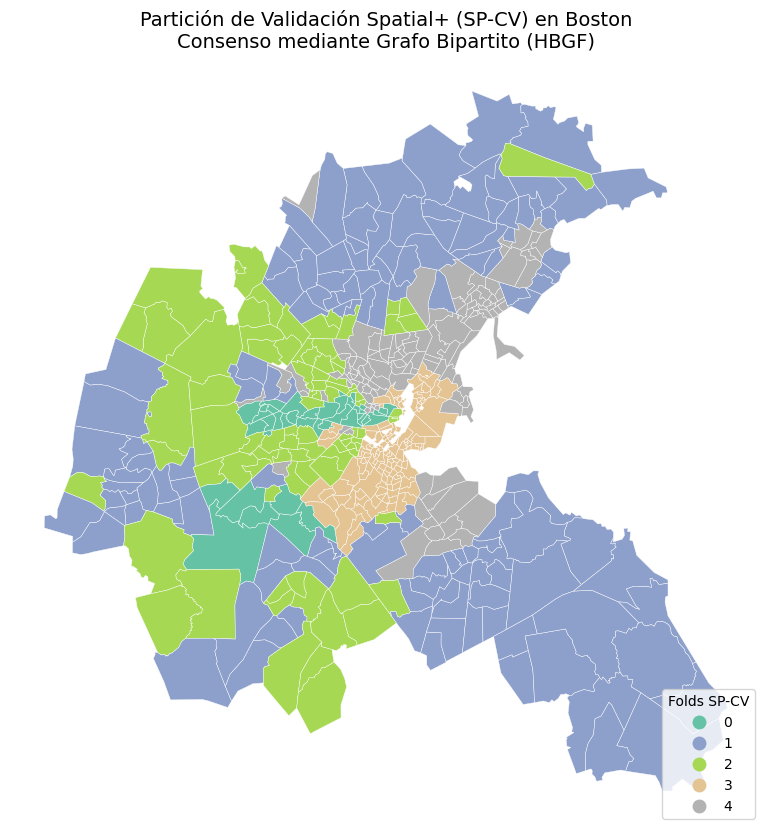

In [20]:
import matplotlib.pyplot as plt

# Configuramos el gráfico
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Graficamos los polígonos de Glasgow coloreados por su número de Fold
gdf.plot(
    column='fold_spatial_plus', 
    cmap='Set2',          # Paleta de colores cualitativa y limpia
    categorical=True, 
    legend=True, 
    legend_kwds={'title': "Folds SP-CV", 'loc': 'lower right'},
    edgecolor='white',    # Línea blanca fina para separar los distritos
    linewidth=0.3,
    ax=ax
)

plt.title("Partición de Validación Spatial+ (SP-CV) en Boston\nConsenso mediante Grafo Bipartito (HBGF)", fontsize=14)
plt.axis('off') # Quitamos los ejes para que luzca como un mapa limpio
plt.show()

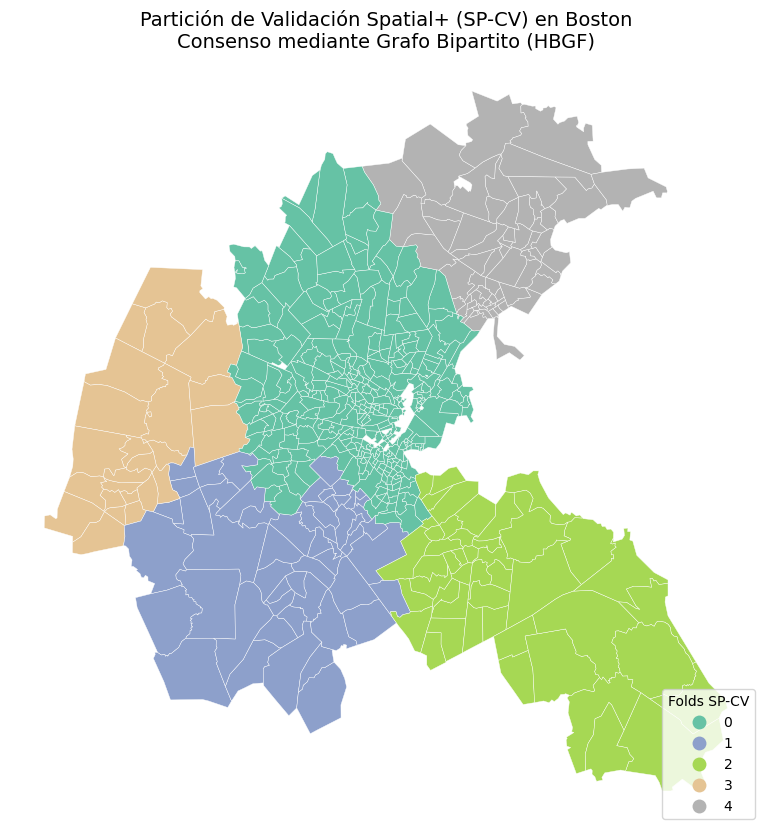

In [16]:
# ------------------------------------------------------------
# 10. VISUALIZACIÓN DE FOLDS
# ------------------------------------------------------------

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

gdf_final.plot(
    column="fold",
    cmap="Set2",
    categorical=True,
    legend=True,
    legend_kwds={"title": "Folds SP-CV", "loc": "lower right"},
    edgecolor="white",
    linewidth=0.3,
    ax=ax
)

plt.title(
    "Partición de Validación Spatial+ (SP-CV) en Boston\n"
    "Consenso mediante Grafo Bipartito (HBGF)",
    fontsize=14
)

plt.axis("off")
plt.show()